## Case 3: Pure PINN Model

A physics-informed neural network using governing ODE and provided intitial conditions 

# 1. Environment Initialization

Set the seed for reproducibility with each iteration and establish hardware/mathematical precision.

In [16]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import math

# Reproducibility (ensures we get same random numbers each time we run the code)
seed = 33
np.random.seed(seed)  
torch.manual_seed(seed)

# Concise device selection
device = "cuda" if torch.cuda.is_available() else "cpu"

# Set double precision (float64, rather than float32) for physics accuracy
torch.set_default_dtype(torch.float64)

print(f"Running on: {device}")

Running on: cpu


Parameter Set-up for  $\ m\frac{d^2 u}{dt^2} + \mu \frac{du}{dt} + k u = 0$

delta = 2.0
omega0 = 20.0
omega_d = 19.8997487421324


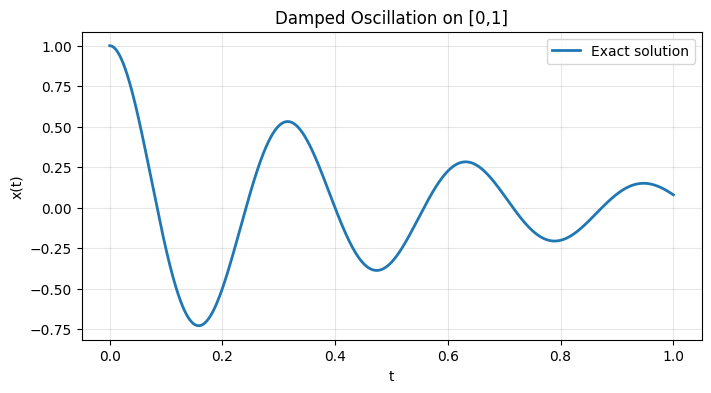

In [17]:
# Parameters
m = 0.09869604401089357
mu = 0.3947841760435743
k = (2 * math.pi) ** 2

# I.C.
x0 = 1.0 # position at t=0
v0 = 0.0 # velocity at t=0
# Time Domain
t0 = 0.0
tf = 1.0

delta = mu / (2*m)
omega0 = np.sqrt(k/m)
omega_d = np.sqrt(omega0**2 - delta**2)

print("delta =", delta)
print("omega0 =", omega0)
print("omega_d =", omega_d)

def exact_solution(t):
    return np.exp(-delta*t) * (np.cos(omega_d*t) + (delta/omega_d)*np.sin(omega_d*t))

def mse_np(y_pred, y_true):
    return np.mean((y_pred - y_true)**2)

def max_abs_error(y_pred, y_true):
    return np.max(np.abs(y_pred - y_true))

# Fine grid for testing and plotting
t_full = np.linspace(t0, tf, 2000)
x_full = exact_solution(t_full)

plt.figure(figsize=(8,4))
plt.plot(t_full, x_full, linewidth=2, label="Exact solution")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Damped Oscillation on [0,1]")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


## 2. Training PINN on provided initial conditions

In [23]:
import torch
import torch.nn as nn

class PINN(nn.Module):
    def __init__(self, hidden_units=64, hidden_layers=4):
        super().__init__()
        layers = [nn.Linear(1, hidden_units), nn.Tanh()]
        for _ in range(hidden_layers - 1):
            layers += [nn.Linear(hidden_units, hidden_units), nn.Tanh()]
        layers += [nn.Linear(hidden_units, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, t):
        # N = neural network's raw prediction
        N = self.net(t)
        # Force the initial conditions (using your global x0 and v0)
        return x0 + v0 * t + (t ** 2) * N 


def pinn_loss(model, col_cat_t, m, mu, k):
    # 1. .clone() makes separate copy
    # 2. .detach() wipes out the gradient history (so we can compute new gradients)
    # 3. .requires_grad_(True) tells PyTorch to track gradients for this tensor
    col_cat_t = col_cat_t.clone().detach().requires_grad_(True)
    
    x_pred = model(col_cat_t)
    
    """ Velocity
    ---------------
    1. Derives x_pred w.r.t. col_cat_t
    2. Multiplies by vector of ones to reduce dimension
    3. Saves math logic for next input 
    4. 'Grad_outputs' collapses the weird matrix into a vector 
    5. '[0]' cleans up vector"""
    x_t = torch.autograd.grad(x_pred, col_cat_t, grad_outputs=torch.ones_like(x_pred), create_graph=True)[0]
    
    # Acceleration
    x_tt = torch.autograd.grad(x_t, col_cat_t, grad_outputs=torch.ones_like(x_t), create_graph=True)[0]
    
    residual = m*x_tt + mu*x_t + k*x_pred
    return torch.mean(residual**2)


def train_pinn(model, col_cat_t, m, mu, k, adam_epochs=10000, lbfgs_max_iter=500, lr=1e-3, print_every=500):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = []

    for epoch in range(1, adam_epochs + 1):
        model.train()
        optimizer.zero_grad()
        # FIXED: Passed m, mu, k into pinn_loss
        loss = pinn_loss(model, col_cat_t, m, mu, k)
        loss.backward()
        optimizer.step()
        history.append(loss.item())
        
        # only prints certain epochs to avoid expensive, time-consuming computation
        if epoch == 1 or epoch % print_every == 0:
            print(f"Adam epoch {epoch:5d}/{adam_epochs} | PINN loss = {loss.item():.8e}")
    
    optimizer_lbfgs = torch.optim.LBFGS(
        model.parameters(), lr=0.5, max_iter=lbfgs_max_iter,
        tolerance_grad=1e-10, tolerance_change=1e-12,
        history_size=100, line_search_fn="strong_wolfe"
    )

    # Efficiates Strong Wolfe process  
    def closure():
        optimizer_lbfgs.zero_grad()
        # FIXED: Passed m, mu, k into pinn_loss
        loss = pinn_loss(model, col_cat_t, m, mu, k)
        loss.backward()
        return loss

    optimizer_lbfgs.step(closure)
    # FIXED: Passed m, mu, k into pinn_loss
    final_loss = pinn_loss(model, col_cat_t, m, mu, k)
    history.append(final_loss.item())
    print(f"LBFGS final PINN loss = {final_loss.item():.8e}")
    return history


# This function stands completely on its own outside of train_pinn, so it resets to 0 spaces!
def predict(model, t):
    model.eval()
    # Note: If your model throws a runtime error here, change torch.float64 to torch.float32
    t_tensor = torch.tensor(t, dtype=torch.float64, device=device).reshape(-1, 1)
    with torch.no_grad():
        pred = model(t_tensor)
    return pred.cpu().numpy().flatten()

## 3. Collocation points & training

The model is trained only by minimizing the differential equation residual via mean squared error (MSE).

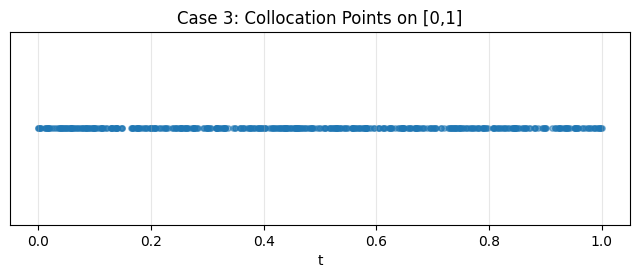

Adam epoch     1/10000 | PINN loss = 1.68359683e+03
Adam epoch   500/10000 | PINN loss = 1.78018230e+02
Adam epoch  1000/10000 | PINN loss = 1.30554458e+02
Adam epoch  1500/10000 | PINN loss = 1.06771134e+02
Adam epoch  2000/10000 | PINN loss = 9.52663365e+01
Adam epoch  2500/10000 | PINN loss = 7.94401501e+01
Adam epoch  3000/10000 | PINN loss = 7.99540075e+01
Adam epoch  3500/10000 | PINN loss = 6.80470642e+01
Adam epoch  4000/10000 | PINN loss = 6.32316174e+01
Adam epoch  4500/10000 | PINN loss = 5.52886162e+01
Adam epoch  5000/10000 | PINN loss = 5.16291611e+01
Adam epoch  5500/10000 | PINN loss = 4.73012772e+01
Adam epoch  6000/10000 | PINN loss = 4.40657403e+01
Adam epoch  6500/10000 | PINN loss = 4.11657709e+01
Adam epoch  7000/10000 | PINN loss = 5.37863631e+01
Adam epoch  7500/10000 | PINN loss = 4.74681722e+01
Adam epoch  8000/10000 | PINN loss = 4.32496568e+01
Adam epoch  8500/10000 | PINN loss = 4.16118996e+01
Adam epoch  9000/10000 | PINN loss = 3.81379477e+01
Adam epoch  

In [24]:
n_col_cat = 500

# Use random collocation points plus endpoints for stronger coverage.
t_random = torch.rand(n_col_cat - 2, 1, dtype=torch.float64, device=device)
t_random = t0 + (tf - t0)*t_random

t_endpoints = torch.tensor([[t0], [tf]], dtype=torch.float64, device=device)
t_collocation = torch.cat([t_endpoints, t_random], dim=0)

plt.figure(figsize=(8,2.5))
plt.scatter(t_collocation.detach().cpu().numpy(), np.zeros_like(t_collocation.detach().cpu().numpy()), s=15, alpha=0.5)
plt.xlabel("t")
plt.yticks([])
plt.title("Case 3: Collocation Points on [0,1]")
plt.grid(alpha=0.3)
plt.show()
# recall physics constants
m = 0.09869604401089357
mu = 0.3947841760435743
k = (2 * math.pi) ** 2
model_case3 = PINN(hidden_units=64, hidden_layers=4)
history_case3 = train_pinn(model_case3, t_collocation, m, mu, k, adam_epochs=10000, lbfgs_max_iter=500, lr=1e-3, print_every=500)


## 4. PINN predication vs. analytical solution comparison

Case 3: Pure PINN MSE on [0,1]: 0.000615238378235717
Case 3: Pure PINN Max Abs Error on [0,1]: 0.04574509139967599


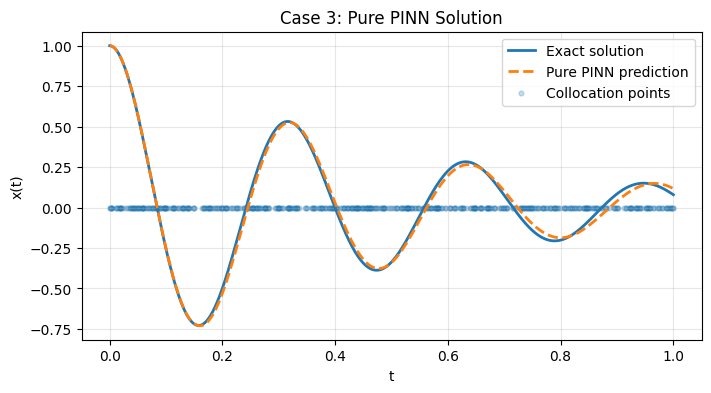

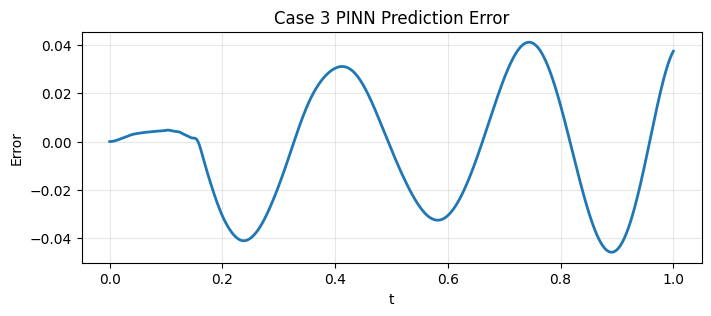

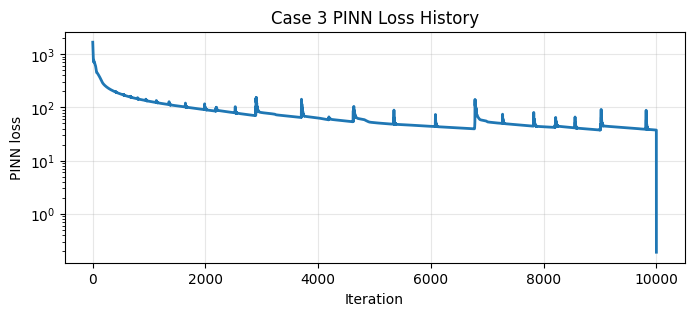

In [25]:
x_pred_case3 = predict(model_case3, t_full)

print("Case 3: Pure PINN MSE on [0,1]:", mse_np(x_pred_case3, x_full))
print("Case 3: Pure PINN Max Abs Error on [0,1]:", max_abs_error(x_pred_case3, x_full))


plt.figure(figsize=(8,4))
plt.plot(t_full, x_full, linewidth=2, label="Exact solution")
plt.plot(t_full, x_pred_case3, "--", linewidth=2, label="Pure PINN prediction")
plt.scatter(t_collocation.detach().cpu().numpy(), np.zeros_like(t_collocation.detach().cpu().numpy()), s=12, alpha=0.25, label="Collocation points")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Case 3: Pure PINN Solution")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(8,3))
plt.plot(t_full, x_pred_case3 - x_full, linewidth=2)
plt.xlabel("t")
plt.ylabel("Error")
plt.title("Case 3 PINN Prediction Error")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8,3))
plt.semilogy(history_case3, linewidth=2)
plt.xlabel("Iteration")
plt.ylabel("PINN loss")
plt.title("Case 3 PINN Loss History")
plt.grid(alpha=0.3)
plt.show()
